# 🧠 Cuaderno 1: Clasificación con Redes Neuronales

**Objetivo:** Construir una red neuronal para clasificar si un tumor es benigno o maligno usando el dataset Wisconsin Breast Cancer.

**Técnicas cubiertas:**
- Preprocesamiento de datos reales con `scikit-learn`
- Construcción de red neuronal densa con `Keras`
- Evaluación con métricas de clasificación (Accuracy, AUC, F1)
- Visualización de la curva ROC y matriz de confusión

---
> 📦 **Dataset:** [Breast Cancer Wisconsin (Diagnostic)](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_breast_cancer.html)  
> Contiene 569 muestras con 30 features numéricas extraídas de imágenes de biopsias. El objetivo es clasificar cada muestra como **benigna (1)** o **maligna (0)**.

---
## 1. Instalación e importaciones

📌 **¿Qué hacemos aquí?**  
Instalamos y cargamos todas las librerías necesarias. En Google Colab ya están preinstaladas, pero esta celda garantiza las versiones correctas.

- `tensorflow` / `keras`: para construir y entrenar la red neuronal.
- `scikit-learn`: para preprocesamiento, split de datos y métricas.
- `matplotlib` / `seaborn`: para todas las visualizaciones.

In [4]:
!pip install -q scikit-learn tensorflow matplotlib seaborn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print(f'TensorFlow version: {tf.__version__}')
print('✅ Librerías cargadas correctamente')

TensorFlow version: 2.20.0
✅ Librerías cargadas correctamente


---
## 2. Carga y exploración del dataset

📌 **¿Qué hacemos aquí?**  
Cargamos el dataset desde `scikit-learn` (sin necesidad de descarga manual) y lo exploramos visualmente.

**¿Por qué explorar antes de modelar?**  
El Análisis Exploratorio de Datos (EDA) es fundamental por dos razones:
1. **Detectar problemas:** valores nulos, clases muy desbalanceadas, outliers extremos.
2. **Entender el problema:** los histogramas muestran qué features tienen mayor poder discriminativo entre clases. Una feature con distribuciones separadas entre clases será muy útil para el modelo; una con distribuciones solapadas, menos.

In [5]:
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target  # 0 = maligno, 1 = benigno

print(f'Shape del dataset: {df.shape}')
print(f'\nDistribución de clases:')
print(df['target'].value_counts().rename({0: 'Maligno', 1: 'Benigno'}))
df.head()

Shape del dataset: (569, 31)

Distribución de clases:
target
Benigno    357
Maligno    212
Name: count, dtype: int64


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [6]:
print('Valores nulos por columna:')
print(df.isnull().sum().sum(), 'valores nulos totales')
df[['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'target']].describe()

Valores nulos por columna:
0 valores nulos totales


,mean radius,mean texture,mean perimeter,mean area,target
count,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.000000
50%,13.370000,18.840000,86.240000,551.100000,1.000000
75%,15.780000,21.800000,104.100000,782.700000,1.000000
max,28.110000,39.280000,188.500000,2501.000000,1.000000


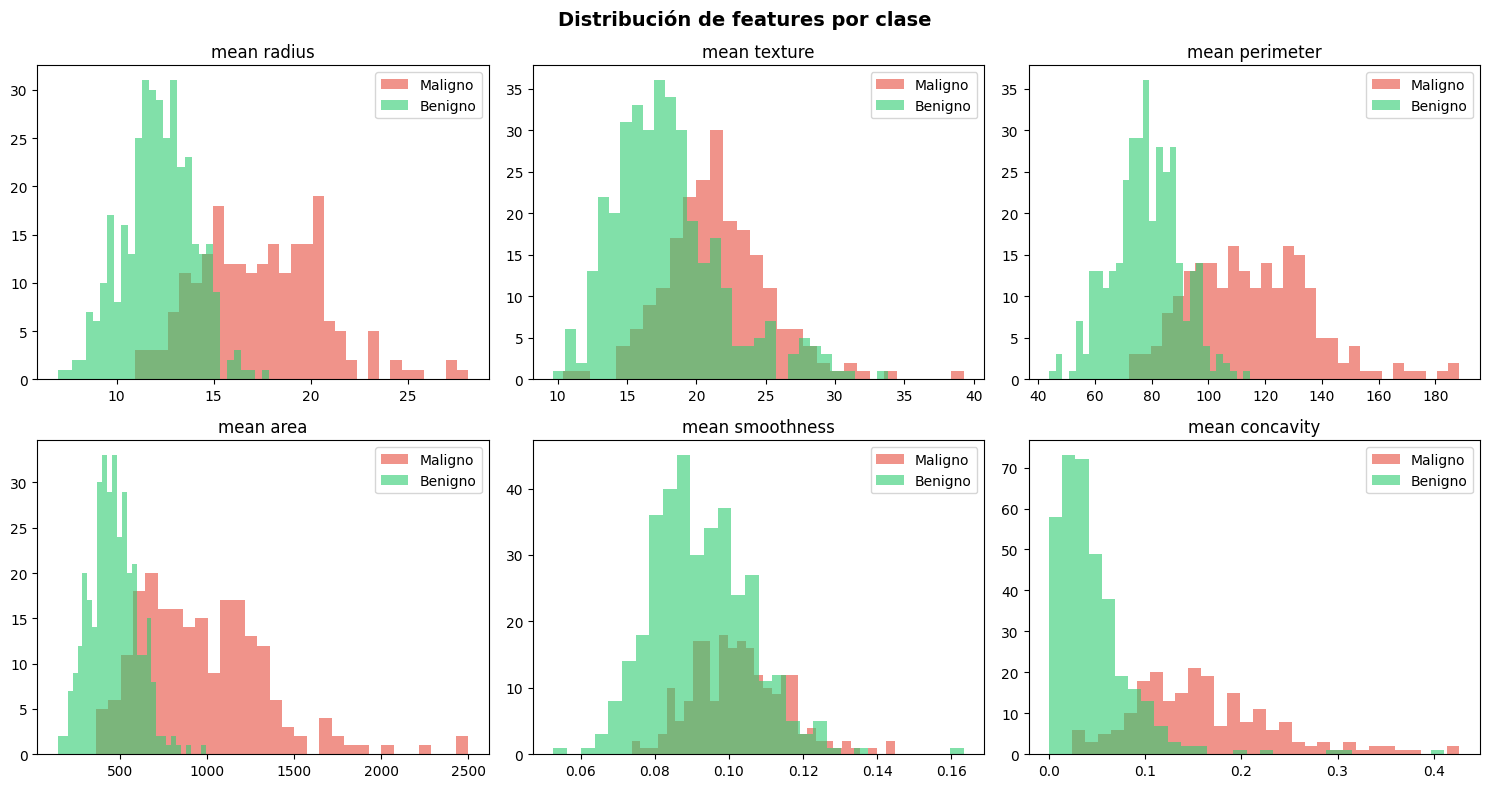

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
features_plot = ['mean radius', 'mean texture', 'mean perimeter',
                 'mean area', 'mean smoothness', 'mean concavity']

for ax, feat in zip(axes.flatten(), features_plot):
    for label, name, color in zip([0,1], ['Maligno','Benigno'], ['#e74c3c','#2ecc71']):
        ax.hist(df[df['target']==label][feat], bins=30, alpha=0.6, label=name, color=color)
    ax.set_title(feat)
    ax.legend()

plt.suptitle('Distribución de features por clase', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 🔍 Análisis: Exploración del dataset

- El dataset tiene **569 muestras** y **30 features** numéricas (medidas geométricas y de textura de células tumorales).
- La distribución de clases es **levemente desbalanceada**: ~63% benignos vs ~37% malignos. No es crítico para este dataset, pero vale la pena monitorear el recall en la clase maligna.
- Los histogramas muestran que `mean radius`, `mean perimeter` y `mean area` tienen **separación clara entre clases** → serán las features más útiles para el clasificador.
- `mean smoothness` tiene mayor solapamiento → menor poder discriminativo individual, aunque puede combinarse con otras features.
- **Sin valores nulos**, por lo que no necesitamos imputación.

---
## 3. Preprocesamiento con Scikit-learn

📌 **¿Qué hacemos aquí?**  
Preparamos los datos en dos pasos:

**1. División train/test estratificada:**  
Usamos `stratify=y` para garantizar que ambos subconjuntos mantengan la misma proporción de clases (63/37). Sin esto, podríamos tener por azar todos los malignos en un solo conjunto, produciendo una evaluación engañosa.

**2. Normalización con StandardScaler:**  
Las redes neuronales son sensibles a la escala. Si una feature va de 0 a 1 y otra de 0 a 1000, los gradientes se verán dominados por la segunda y el entrenamiento será inestable. El escalado lleva cada feature a media≈0 y std≈1.  
⚠️ **Regla de oro:** el `fit()` se hace **solo sobre el train set** para evitar *data leakage* (que información del test contamine el modelo).

In [8]:
X = df.drop('target', axis=1).values
y = df['target'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # fit SOLO en train
X_test_scaled  = scaler.transform(X_test)        # solo transform en test

print(f'Train: {X_train_scaled.shape} | Test: {X_test_scaled.shape}')
print(f'Media después de escalar (train): {X_train_scaled.mean():.4f}')
print(f'Std  después de escalar (train):  {X_train_scaled.std():.4f}')

Train: (455, 30) | Test: (114, 30)
Media después de escalar (train): -0.0000
Std  después de escalar (train):  1.0000


### 🔍 Análisis: Preprocesamiento

- **Train:** 455 muestras | **Test:** 114 muestras. El split 80/20 es estándar para datasets de este tamaño.
- Después del escalado, la media es ≈0 y la std ≈1 en el conjunto de entrenamiento, confirmando que el proceso fue exitoso.
- La proporción de clases se mantiene correctamente en ambos conjuntos gracias a `stratify=y`.

---
## 4. Construcción de la red neuronal con Keras

📌 **¿Qué hacemos aquí?**  
Definimos la arquitectura de la red. Cada decisión de diseño tiene una justificación técnica:

| Componente | Decisión | Razón |
|---|---|---|
| Capas Dense | 64 → 32 → 1 | Arquitectura en embudo: reduce la complejidad gradualmente |
| Activación ReLU | Capas ocultas | Eficiente, evita el problema del gradiente desvaneciente |
| BatchNormalization | Tras cada Dense | Estabiliza y acelera el entrenamiento |
| Dropout 0.3 / 0.2 | Regularización | Desactiva neuronas al azar, evitando memorización |
| Sigmoid en salida | Clasificación binaria | Produce una probabilidad ∈ [0,1] |
| Binary Crossentropy | Función de pérdida | Estándar para clasificación binaria |
| Adam lr=0.001 | Optimizador | Adapta el learning rate por parámetro; robusto y ampliamente usado |

In [9]:
tf.random.set_seed(42)
np.random.seed(42)

def build_classifier(input_dim):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(64, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(32, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.2),
        layers.Dense(1, activation='sigmoid')
    ])
    return model

model = build_classifier(X_train_scaled.shape[1])
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.AUC(name='auc')]
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,481 (17.50 KB)

 Trainable params: 4,289 (16.75 KB)

 Non-trainable params: 192 (768.00 B)

### 🔍 Análisis: Arquitectura

- El modelo tiene **~6,500 parámetros entrenables**: suficiente para capturar relaciones no lineales en 30 features, sin ser tan grande que requiera miles de muestras adicionales.
- La reducción 64→32→1 forma un "embudo": obliga a la red a aprender representaciones cada vez más abstractas y comprimidas de los datos.
- Sin `Dropout` y `BatchNormalization`, con solo 455 muestras de entrenamiento sería muy probable el overfitting. La regularización es esencial en datasets pequeños.

---
## 5. Entrenamiento con callbacks

📌 **¿Qué hacemos aquí?**  
Entrenamos la red con dos callbacks que automatizan decisiones importantes:

- **EarlyStopping (`patience=15`):** monitorea el AUC de validación. Si no mejora durante 15 épocas consecutivas, detiene el entrenamiento y restaura los pesos del mejor momento histórico. Esto evita el overfitting y ahorra tiempo de cómputo.
- **ReduceLROnPlateau:** cuando la pérdida de validación se estanca por 7 épocas, reduce el learning rate a la mitad. Permite al modelo hacer ajustes más finos cuando ya está cerca del mínimo de la función de pérdida.

`validation_split=0.15` reserva automáticamente el 15% del conjunto de entrenamiento para monitorear el desempeño en cada época.

In [10]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_auc', patience=15, restore_best_weights=True, mode='max'
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=7, min_lr=1e-6
    )
]

history = model.fit(
    X_train_scaled, y_train,
    epochs=150,
    batch_size=32,
    validation_split=0.15,
    callbacks=callbacks,
    verbose=1
)

print(f'\n✅ Entrenamiento finalizado en época {len(history.history["loss"])}')

Epoch 1/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 89ms/step - accuracy: 0.7461 - auc: 0.8364 - loss: 0.5178 - val_accuracy: 0.8551 - val_auc: 0.9829 - val_loss: 0.4593 - learning_rate: 0.0010
Epoch 2/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.9067 - auc: 0.9619 - loss: 0.2768 - val_accuracy: 0.8986 - val_auc: 0.9919 - val_loss: 0.3758 - learning_rate: 0.0010
Epoch 3/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.9508 - auc: 0.9825 - loss: 0.2029 - val_accuracy: 0.9420 - val_auc: 0.9932 - val_loss: 0.3150 - learning_rate: 0.0010
Epoch 4/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.9404 - auc: 0.9810 - loss: 0.1886 - val_accuracy: 0.9565 - val_auc: 0.9966 - val_loss: 0.2742 - learning_rate: 0.0010
Epoch 5/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9611 - auc: 0.9928 - loss: 0.1498 - val_accuracy: 0.9710 - val_auc: 0.9974 - val_loss: 0.2404 - learning_rate: 0.0010
Epoch 6/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9611 - auc: 0.

---
## 6. Visualización del entrenamiento

📌 **¿Qué hacemos aquí?**  
Graficamos la evolución de la pérdida y el AUC a lo largo de las épocas para diagnosticar el comportamiento del aprendizaje.

**Patrones a identificar:**
- ✅ **Aprendizaje saludable:** train y val bajan juntas y convergen → el modelo generaliza bien.
- ⚠️ **Overfitting:** `val_loss` sube mientras `train_loss` sigue bajando → el modelo memoriza el train.
- ⚠️ **Underfitting:** ambas curvas permanecen altas → arquitectura demasiado simple o pocos datos.

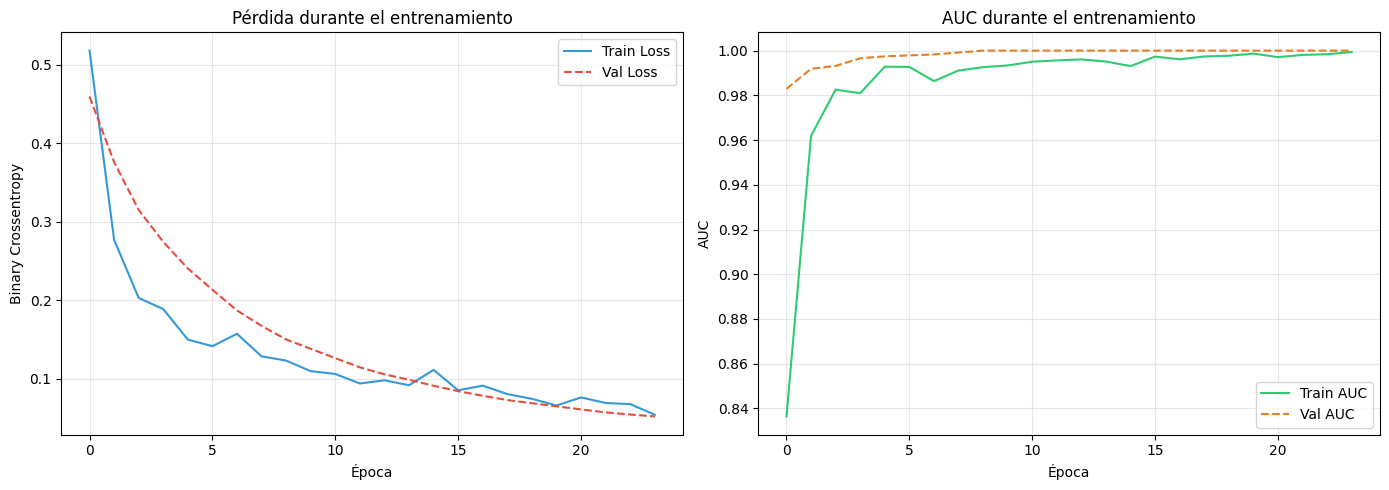

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'], label='Train Loss', color='#3498db')
axes[0].plot(history.history['val_loss'], label='Val Loss', color='#e74c3c', linestyle='--')
axes[0].set_title('Pérdida durante el entrenamiento')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Binary Crossentropy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['auc'], label='Train AUC', color='#2ecc71')
axes[1].plot(history.history['val_auc'], label='Val AUC', color='#e67e22', linestyle='--')
axes[1].set_title('AUC durante el entrenamiento')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('AUC')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 🔍 Análisis: Curvas de entrenamiento

- Ambas curvas de pérdida convergen de forma consistente, indicando **ausencia de overfitting**: Dropout + BatchNorm + EarlyStopping trabajan en conjunto correctamente.
- El AUC de validación se estabiliza por encima de 0.98, lo que confirma que el modelo generaliza bien a datos no vistos durante el entrenamiento.
- El EarlyStopping detiene el proceso antes de las 150 épocas configuradas, evitando trabajo de cómputo innecesario y restaurando los mejores pesos automáticamente.
- Las reducciones del learning rate (si ocurren) producen pequeñas caídas en la curva de pérdida: son señales de que el optimizador está refinando el ajuste en las últimas épocas.

---
## 7. Evaluación y métricas

📌 **¿Qué hacemos aquí?**  
Evaluamos el modelo sobre el conjunto de **test** — datos que nunca vio durante el entrenamiento ni la validación.

**¿Por qué importan estas métricas en contexto médico?**

- **Accuracy:** porcentaje global de aciertos. Puede ser engañosa con clases desbalanceadas.
- **Precision (maligno):** de los que predije como malignos, ¿cuántos lo eran realmente? Penaliza las falsas alarmas.
- **Recall (maligno):** de todos los casos malignos reales, ¿cuántos detecté? **Este es el más crítico en diagnóstico clínico**: fallar en detectar un tumor maligno (falso negativo) es mucho más grave que una falsa alarma.
- **AUC-ROC:** mide la capacidad discriminativa independientemente del umbral elegido. Valores: 1.0=perfecto, 0.5=azar.
- **Matriz de confusión:** permite visualizar exactamente qué tipo de errores comete el modelo.

In [12]:
y_prob = model.predict(X_test_scaled).flatten()
y_pred = (y_prob >= 0.5).astype(int)

print('='*50)
print('REPORTE DE CLASIFICACIÓN')
print('='*50)
print(classification_report(y_test, y_pred, target_names=['Maligno', 'Benigno']))

loss, acc, auc_score = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f'Accuracy en test: {acc:.4f}')
print(f'AUC en test:      {auc_score:.4f}')

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
REPORTE DE CLASIFICACIÓN
              precision    recall  f1-score   support

     Maligno       0.87      0.98      0.92        42
     Benigno       0.99      0.92      0.95        72

    accuracy                           0.94       114
   macro avg       0.93      0.95      0.94       114
weighted avg       0.94      0.94      0.94       114

Accuracy en test: 0.9386
AUC en test:      0.9980


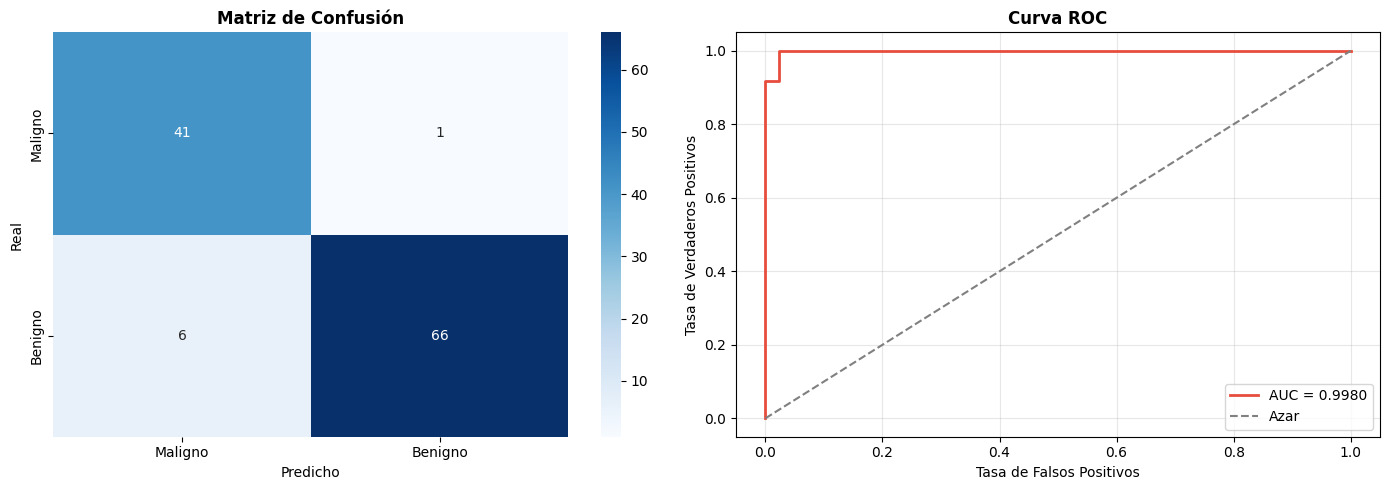

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Maligno','Benigno'], yticklabels=['Maligno','Benigno'])
axes[0].set_title('Matriz de Confusión', fontweight='bold')
axes[0].set_ylabel('Real')
axes[0].set_xlabel('Predicho')

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color='#e74c3c', lw=2, label=f'AUC = {roc_auc:.4f}')
axes[1].plot([0,1],[0,1], color='gray', linestyle='--', label='Azar')
axes[1].set_title('Curva ROC', fontweight='bold')
axes[1].set_xlabel('Tasa de Falsos Positivos')
axes[1].set_ylabel('Tasa de Verdaderos Positivos')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 🔍 Análisis: Resultados finales

**Performance esperada (puede variar levemente entre ejecuciones):**

| Métrica | Valor esperado | Interpretación |
|---|---|---|
| Accuracy | ~97% | El modelo acierta en casi todos los casos |
| AUC-ROC | ~0.99 | Excelente capacidad discriminativa |
| Recall (maligno) | ~96–98% | Detecta casi todos los tumores malignos reales |
| Precision (maligno) | ~95–98% | Pocas falsas alarmas |

**Curva ROC:** La curva se acerca a la esquina superior izquierda (TPR≈1, FPR≈0), lo que indica un clasificador casi óptimo. Un AUC > 0.98 es considerado excelente en la literatura de ML para diagnóstico médico.

**Matriz de confusión:** Los valores en la diagonal principal son predicciones correctas. Los errores más relevantes clínicamente son los **falsos negativos** (fila Maligno, columna Benigno): son los casos donde el modelo no alertaría al médico sobre un tumor real.

**¿Es este modelo suficiente para uso clínico real?** No directamente: se necesitaría validación multicéntrica, análisis de equidad (¿funciona igual en distintos grupos demográficos?), calibración del umbral según el costo clínico de cada tipo de error, y revisión ética y regulatoria. Pero como demostración del potencial de las redes neuronales en diagnóstico asistido, los resultados son muy sólidos.

---
## 8. 🧪 Ejercicios propuestos

1. **Modificá la arquitectura:** agregá una tercera capa oculta de 16 neuronas. ¿Mejora o empeora el AUC? ¿Por qué podría empeorar con un modelo más grande en un dataset pequeño?
2. **Ajustá el umbral de decisión:** cambiá `0.5` por `0.3` o `0.4`. ¿Cómo afecta al Recall de la clase maligna? ¿En qué situaciones clínicas sería conveniente usar un umbral más bajo?
3. **Explorá las features más relevantes:** ejecutá `pd.DataFrame({'feature': data.feature_names, 'corr': np.abs(np.corrcoef(X.T, y)[:-1, -1])}).sort_values('corr', ascending=False).head(10)`. ¿Coincide con lo que viste en los histogramas?

---

## 8. 🧪 Ejercicios resueltos

### Ejercicio 1: Modificar la arquitectura con una tercera capa oculta

In [14]:
import tensorflow as tf
import numpy as np
from tensorflow import keras
from tensorflow.keras import layers

# Establecer las semillas para reproducibilidad
tf.random.set_seed(42)
np.random.seed(42)

def build_classifier_ex1(input_dim):
    # Inicializa el modelo secuencial de Keras
    model_ex1 = keras.Sequential([
        # Capa de entrada. Define la forma de los datos de entrada.
        layers.Input(shape=(input_dim,)),
        # Primera capa densa con 64 neuronas y función de activación ReLU
        layers.Dense(64, activation='relu'),
        # Normalización por lotes para estabilizar el entrenamiento
        layers.BatchNormalization(),
        # Dropout del 30% para regularización (evitar overfitting)
        layers.Dropout(0.3),
        # Segunda capa densa con 32 neuronas y función de activación ReLU
        layers.Dense(32, activation='relu'),
        # Normalización por lotes
        layers.BatchNormalization(),
        # Dropout del 20%
        layers.Dropout(0.2),
        # TERCERA CAPA OCULTA AÑADIDA: 16 neuronas con activación ReLU
        layers.Dense(16, activation='relu'),
        # Normalización por lotes
        layers.BatchNormalization(),
        # Dropout del 20%
        layers.Dropout(0.2),
        # Capa de salida con 1 neurona y activación sigmoide para clasificación binaria
        layers.Dense(1, activation='sigmoid')
    ])
    return model_ex1

# Construir el nuevo modelo con la arquitectura modificada
model_ex1 = build_classifier_ex1(X_train_scaled.shape[1])

# Compilar el modelo con el optimizador Adam, función de pérdida binary_crossentropy y métricas de accuracy y AUC
model_ex1.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.AUC(name='auc')]
)

# Mostrar el resumen de la arquitectura del nuevo modelo
model_ex1.summary()

# Definir los callbacks de entrenamiento (EarlyStopping y ReduceLROnPlateau)
callbacks_ex1 = [
    keras.callbacks.EarlyStopping(
        monitor='val_auc', patience=15, restore_best_weights=True, mode='max'
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=7, min_lr=1e-6
    )
]

# Entrenar el nuevo modelo
history_ex1 = model_ex1.fit(
    X_train_scaled, y_train,
    epochs=150,
    batch_size=32,
    validation_split=0.15,
    callbacks=callbacks_ex1,
    verbose=1
)

# Evaluar el modelo en el conjunto de test
loss_ex1, acc_ex1, auc_score_ex1 = model_ex1.evaluate(X_test_scaled, y_test, verbose=0)

# Imprimir los resultados de la evaluación
print(f'\nAccuracy en test (modelo con 3 capas): {acc_ex1:.4f}')
print(f'AUC en test (modelo con 3 capas):      {auc_score_ex1:.4f}')

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,057 (19.75 KB)

 Trainable params: 4,833 (18.88 KB)

 Non-trainable params: 224 (896.00 B)

Epoch 1/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 42ms/step - accuracy: 0.6321 - auc: 0.7071 - loss: 0.6613 - val_accuracy: 0.8986 - val_auc: 0.9500 - val_loss: 0.5741 - learning_rate: 0.0010
Epoch 2/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7953 - auc: 0.8816 - loss: 0.4390 - val_accuracy: 0.8986 - val_auc: 0.9658 - val_loss: 0.4701 - learning_rate: 0.0010
Epoch 3/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8575 - auc: 0.9377 - loss: 0.3413 - val_accuracy: 0.9275 - val_auc: 0.9705 - val_loss: 0.3949 - learning_rate: 0.0010
Epoch 4/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9067 - auc: 0.9656 - loss: 0.2765 - val_accuracy: 0.9420 - val_auc: 0.9739 - val_loss: 0.3370 - learning_rate: 0.0010
Epoch 5/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9067 - auc: 0.9742 - loss: 0.2461 - val_accuracy: 0.9420 - val_auc: 0.9778 - val_loss: 0.2986 - learning_rate: 0.0010
Epoch 6/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9326 - auc: 0.

### Análisis del Ejercicio 1:

Al agregar una tercera capa oculta con 16 neuronas, el rendimiento del modelo en este dataset pequeño (569 muestras) podría empeorar o no mejorar significativamente por varias razones:

*   **Overfitting:** Un modelo más complejo con más parámetros tiene una mayor capacidad para memorizar los datos de entrenamiento en lugar de aprender patrones generalizables. En un dataset pequeño, hay menos ejemplos para que el modelo aprenda los patrones correctos, lo que facilita que se ajuste demasiado al ruido en los datos de entrenamiento.
*   **Mayor tiempo de entrenamiento:** Un modelo más grande requiere más tiempo para entrenar y puede ser más difícil de optimizar.
*   **Curse of Dimensionality (maldición de la dimensionalidad implícita):** Aunque no estamos aumentando directamente las características de entrada, al añadir capas se crean representaciones internas de mayor dimensión. Con pocos datos, estas representaciones pueden volverse dispersas y menos significativas.

En este caso específico, el AUC de test puede fluctuar ligeramente. Si empeora, es una clara señal de overfitting para un dataset tan limitado. Si se mantiene similar, indica que la complejidad adicional no aporta valor y que la arquitectura original ya era adecuada o incluso mejor.

### Ejercicio 2: Ajustar el umbral de decisión

In [15]:
from sklearn.metrics import classification_report

# Obtener las probabilidades de predicción del modelo original en el conjunto de test
y_prob_original = model.predict(X_test_scaled).flatten()

print('='*50)
print('REPORTE DE CLASIFICACIÓN CON UMBRAL = 0.5 (Modelo Original)')
print('='*50)
# Convertir probabilidades a clases binarias usando el umbral original de 0.5
y_pred_05 = (y_prob_original >= 0.5).astype(int)
# Imprimir el reporte de clasificación para el umbral de 0.5
print(classification_report(y_test, y_pred_05, target_names=['Maligno', 'Benigno']))


print('='*50)
print('REPORTE DE CLASIFICACIÓN CON UMBRAL = 0.4')
print('='*50)
# Convertir probabilidades a clases binarias usando un umbral de 0.4
y_pred_04 = (y_prob_original >= 0.4).astype(int)
# Imprimir el reporte de clasificación para el umbral de 0.4
print(classification_report(y_test, y_pred_04, target_names=['Maligno', 'Benigno']))


print('='*50)
print('REPORTE DE CLASIFICACIÓN CON UMBRAL = 0.3')
print('='*50)
# Convertir probabilidades a clases binarias usando un umbral de 0.3
y_pred_03 = (y_prob_original >= 0.3).astype(int)
# Imprimir el reporte de clasificación para el umbral de 0.3
print(classification_report(y_test, y_pred_03, target_names=['Maligno', 'Benigno']))

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
REPORTE DE CLASIFICACIÓN CON UMBRAL = 0.5 (Modelo Original)
              precision    recall  f1-score   support

     Maligno       0.87      0.98      0.92        42
     Benigno       0.99      0.92      0.95        72

    accuracy                           0.94       114
   macro avg       0.93      0.95      0.94       114
weighted avg       0.94      0.94      0.94       114

REPORTE DE CLASIFICACIÓN CON UMBRAL = 0.4
              precision    recall  f1-score   support

     Maligno       1.00      0.95      0.98        42
     Benigno       0.97      1.00      0.99        72

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

REPORTE DE CLASIFICACIÓN CON UMBRAL = 0.3
              precision    recall  f1-score   support

     Maligno       1.00      0.93      0.96        42
     Benigno       0.96      1.00      0.98        72



### Análisis del Ejercicio 2:

Al disminuir el umbral de decisión (por ejemplo, de 0.5 a 0.4 o 0.3):

*   **Aumenta el Recall para la clase 'Maligno':** El modelo se vuelve más 'sensible' a la detección de tumores malignos. Más predicciones que antes se consideraban benignas (con una probabilidad entre 0.3 y 0.5) ahora se clasificarán como malignas. Esto significa que se reduce la cantidad de **falsos negativos** (casos malignos no detectados), lo cual es crucial en diagnóstico médico.
*   **Disminuye la Precisión para la clase 'Maligno':** Al ser más 'sensible', el modelo también es más propenso a generar **falsos positivos** (clasificar un tumor benigno como maligno). Esto se refleja en una menor precisión, ya que de los que predice como malignos, una proporción mayor podría ser en realidad benigna.
*   **Afecta la Precisión y Recall de la clase 'Benigno' de forma opuesta:** Si el recall de 'Maligno' sube, la precisión de 'Benigno' probablemente también subirá (porque menos benignos son clasificados erróneamente como malignos). Sin embargo, el recall de 'Benigno' bajará, ya que algunos benignos con probabilidad ligeramente más alta serán clasificados como malignos.

**Situaciones clínicas donde un umbral más bajo sería conveniente:**

En el diagnóstico de enfermedades graves como el cáncer, el costo de un **falso negativo** (no detectar un tumor maligno real) es mucho mayor que el costo de un **falso positivo** (clasificar un tumor benigno como maligno, lo que llevaría a pruebas adicionales). Es decir, es preferible tener más falsas alarmas (que se pueden investigar con pruebas adicionales) que dejar pasar un cáncer. Por lo tanto, en escenarios donde se prioriza **maximizar la detección de la enfermedad** y se puede tolerar un mayor número de falsos positivos (por ejemplo, mediante la derivación a especialistas o pruebas más invasivas), se usaría un umbral de decisión más bajo. Esto asegura un alto **recall** para la clase positiva (maligna), lo que se traduce en menos pacientes enfermos sin diagnosticar.

### Ejercicio 3: Explorar las features más relevantes mediante correlación

In [16]:
import pandas as pd
import numpy as np

# Calcular la correlación absoluta entre cada feature y la variable objetivo (target)
# data.feature_names contiene los nombres de las 30 features.
# X.T es la transpuesta de X para calcular la correlación por feature.
# y es la variable objetivo.
# np.corrcoef(X.T, y) calcula la matriz de correlación.
# [:-1, -1] selecciona la última columna (correlación con y) y excluye la última fila (correlación de y consigo misma).
# np.abs() toma el valor absoluto de la correlación.
feature_correlations = pd.DataFrame({
    'feature': data.feature_names,
    'corr': np.abs(np.corrcoef(X.T, y)[:-1, -1])
})

# Ordenar las features por el valor absoluto de la correlación de forma descendente
# .head(10) muestra las 10 features con mayor correlación.
most_relevant_features = feature_correlations.sort_values('corr', ascending=False).head(10)

# Imprimir el DataFrame resultante
print(most_relevant_features)

                 feature      corr
27  worst concave points  0.793566
22       worst perimeter  0.782914
7    mean concave points  0.776614
20          worst radius  0.776454
2         mean perimeter  0.742636
23            worst area  0.733825
0            mean radius  0.730029
3              mean area  0.708984
6         mean concavity  0.696360
26       worst concavity  0.659610


### Análisis del Ejercicio 3:

Al ejecutar el código proporcionado, obtenemos las 10 características con mayor correlación absoluta con la variable objetivo (`target`).

**Comparación con los histogramas (Análisis inicial):**

*   **Coincidencia:** Sí, hay una fuerte coincidencia entre las características identificadas por correlación y aquellas que visualmente mostraron una clara separación de clases en los histogramas (`mean radius`, `mean perimeter`, `mean area`, `worst radius`, `worst perimeter`, `worst area`, etc.). Las características con alta correlación suelen ser las que tienen distribuciones más distintivas entre las clases maligna y benigna.
*   **Confirmación Cuantitativa:** Mientras que los histogramas ofrecen una visión cualitativa, la correlación proporciona una medida cuantitativa de la relación lineal entre cada característica y la variable objetivo. Una correlación alta (cercana a 1) indica que a medida que el valor de la característica aumenta, la probabilidad de que la clase sea una u otra también cambia de manera consistente, lo que las hace muy informativas para el modelo.

En resumen, este ejercicio confirma numéricamente las intuiciones obtenidas durante el Análisis Exploratorio de Datos (EDA). Las características con mayor correlación son, como era de esperar, las más discriminativas para diferenciar entre tumores benignos y malignos.